# JAX based BCDI phase retrieval

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.60"   # ~20 GiB on a 48 GiB A40

import jax
import jax.numpy as jnp
print(jax.devices())
import h5py

import numpy as np
import sys
import time 
import pynx
import cdiutils
import convexad
from convexad.optimize import *
from convexad.viz import *
from convexad.losses import _center_pad 
from convexad.pynx_reconstruction import *
from scipy.fft import fftshift, ifftshift, fftn, ifftn


[CudaDevice(id=0)]


# Load data

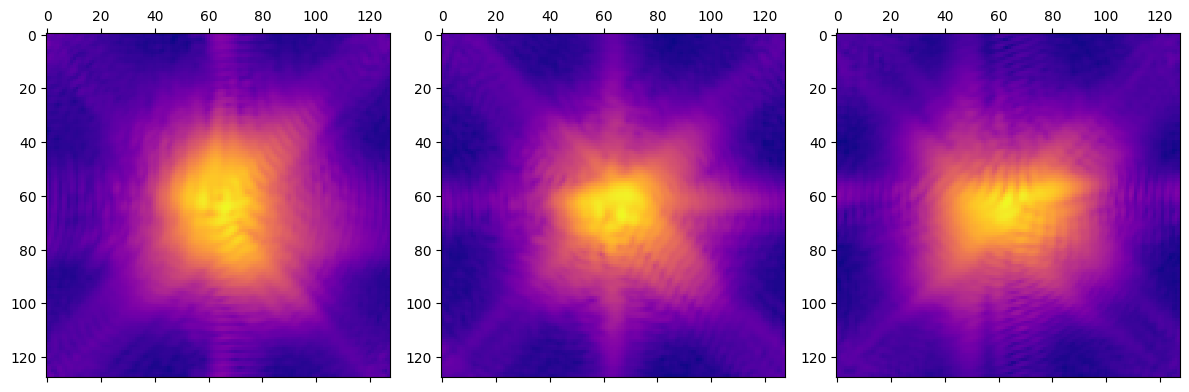

In [2]:
Iobs = np.load("data_prova.npz")["I"].astype(np.float32)
key = jax.random.PRNGKey(0)
plot_3D_projections(Iobs)

# Solve PR

In [7]:
t0 = time.time()

resume = None # To continue: set resume = result

result = reconstruct(
    key,
    Iobs,
    n_restarts = 32,
    N=64,
    size_factor=4.0,
    eps=0.8,
    alpha=0.0,
    beta=0.05,
    metric="mae",
    phase_type="displacement",
    phase_kwargs={'hkl': [2,2,2]},
    support_type="single",
    max_steps=1000,
    learning_rate=0.05,
    decay_steps=500,
    decay_rate=0.9,
    staircase=True,
    b1=0.9,
    b2=0.98,
    eps_adam=1e-6,
    grid_shape=None,
    variant="amsgrad",            # "amsgrad" | "adabelief" | "lion"
    stop_amplitude_grad=False,   
    clip_norm = 1.0,
    resume = resume,
)
print(f"done in {time.time() - t0:.1f}s")

step 400/1000   best loss 0.0965354
interrupted at step 400: pass resume=result to continue
done in 29.8s


In [10]:
print("best loss:", float(result.best_loss))
print("steps per restart:", result.all_steps)


best loss: 0.09653537720441818
steps per restart: [400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 400 400]


In [11]:
support, amplitude, phase = result.evaluate(Iobs)
modulus = amplitude*support
obj = modulus*phase[0] + 1.0j*modulus*phase[1]
# obj = modulus*np.exp(1.0j*phase)


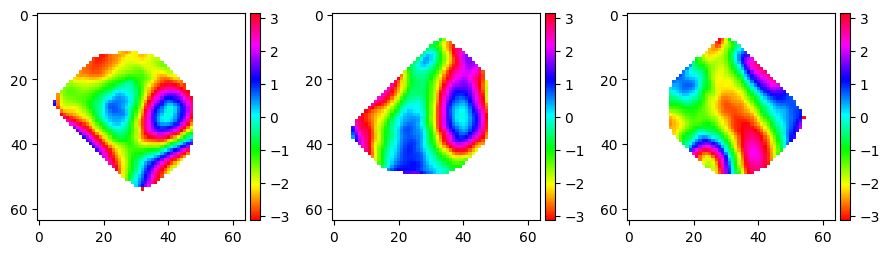

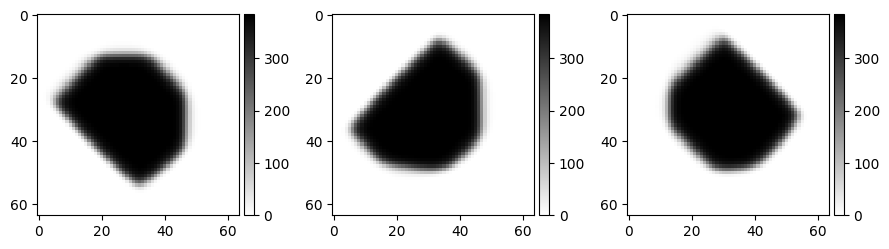

In [12]:
plot_2D_slices_middle_only_phase(obj, unwrap = False)
plot_2D_slices_middle_only_module(obj)

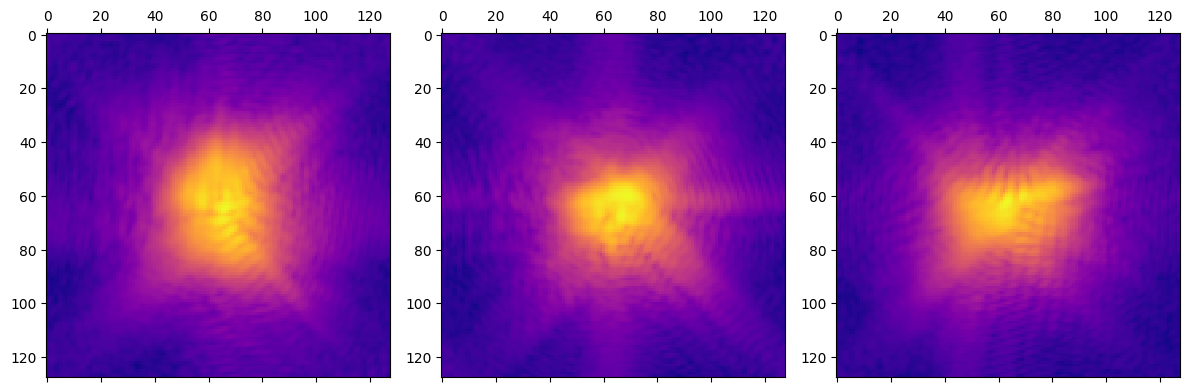

In [13]:

obj_p = _center_pad(obj, Iobs.shape)
Icalc = np.abs(ifftshift(fftn(fftshift(obj_p))))
plot_3D_projections(Icalc)

# PyNX refinement

In [14]:
from pynx.processing_unit import ProcessingUnit
pu = ProcessingUnit()
pu.select_gpu(language="cuda", verbose=True)

Computing speed for available CUDA GPU [ranking by global memory bandwidth]:
                                                  NVIDIA A40:   44 Gb,   522 Gbytes/s  [PCI: 0000:21:00.0]
Using CUDA GPU: NVIDIA A40


True

In [15]:
params = default_cdi_parameters()
params['obj_init'] = obj_p
params['support_threshold_relative'] = 0.25 # np.random.uniform(0.15,0.25)
params['support_update'] = 50
params['fix_support'] = False
params['algo_string'] = 'HIO_00 RAAR_00 ER_400'
params['support_update_border'] = True
params['support_update_border_n'] = 1
params['post_expand'] =(-1,1)
params['tv'] = 0.01
params['tv_er'] = 0.01
params['roi'] = 'full'
params['save_plot'] = False
params['plot_result']  = False

using gaussian convoluted and threshold as support
tv regularization at : 0.01


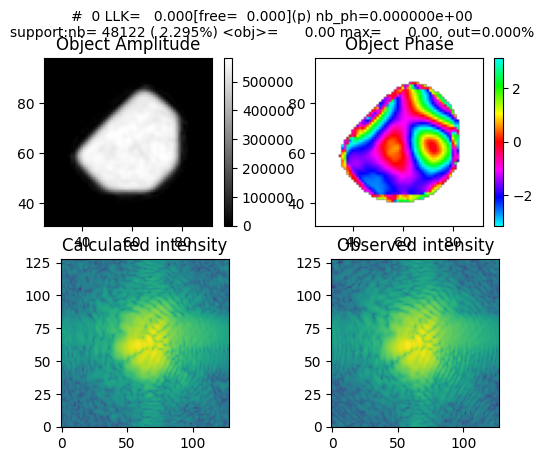

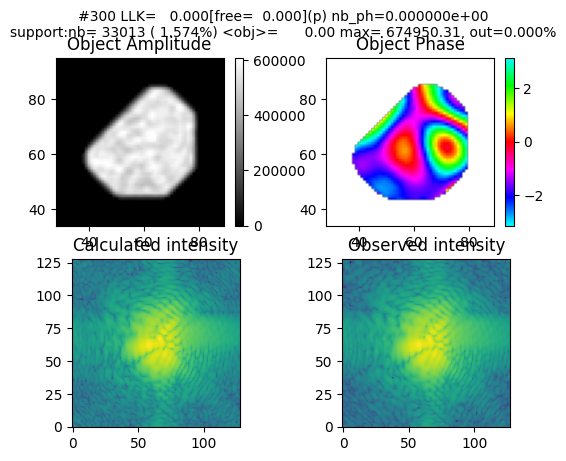

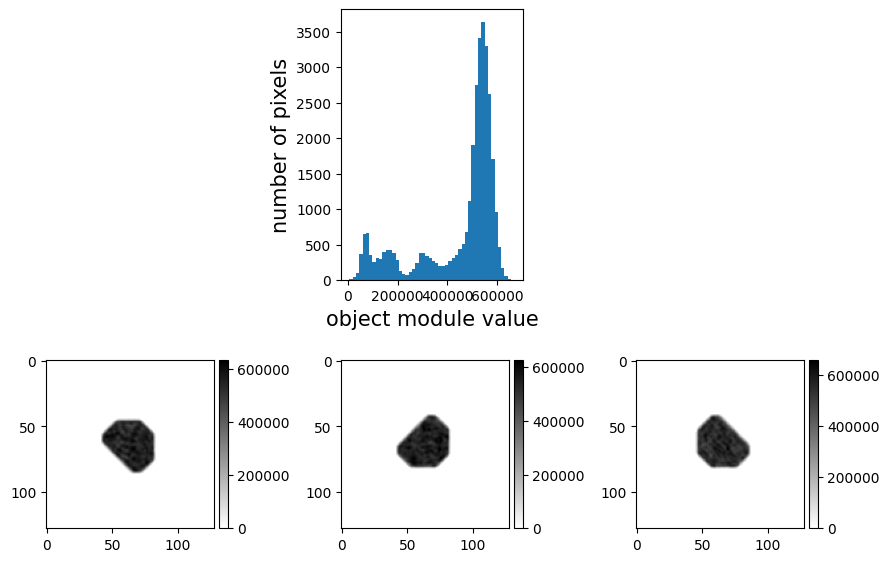

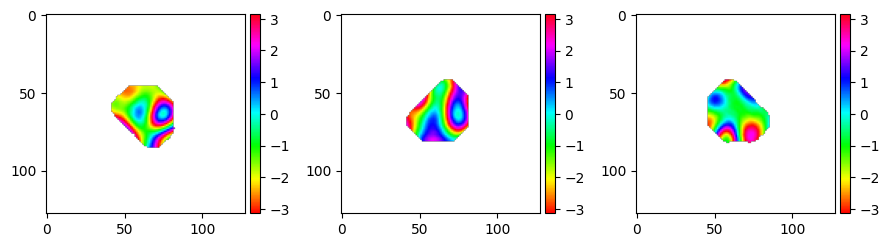

In [16]:
obj3d, llk, support, return_dict = CDI_one_reconstruction(Iobs, params)
Icalc = np.abs(ifftshift(fftn(fftshift(obj3d))))**2
plot_2D_slices_middle_only_module_and_histogram(obj3d)
plot_2D_slices_middle_only_phase(obj3d, threshold_module= .25, unwrap= False)